# Winning a Stock-Picking Competition with Simulation

**The assignment.** In a university investment class, each student picks 10 stocks, explains each pick, and splits a hypothetical \$100,000 among them. The portfolio is bought at the close on **Sep 14, 2026** and valued at the close on **Dec 14, 2026**. The highest return wins.

**Rules.** All 10 stocks must be held, each at **5–20%** of the portfolio. Buy once and hold. Fractional shares are allowed.

**The question.** *How should the money be split to give the best chance of finishing first?*

**Why this isn't a normal investing problem.** Textbook portfolio theory maximizes return per unit of risk (the Sharpe ratio). A winner-take-all contest is different: with 20 rivals, someone with a risky mix usually gets lucky, so a steady portfolio almost never finishes first. What matters is the **probability of beating every rival**, written **P(win)** in this notebook.

**Method in four steps**
1. Simulate hundreds of thousands of possible 3-month futures, built from real price history.
2. In each future, simulate 20 rival students with their own random stocks and weights.
3. Score every allowed way to split the money by how often it finishes first, then fine-tune the best ones.
4. Check the method on past quarters (a backtest).

> **Just want the answer?** The notebook is saved with its results. Jump to **section 10 (Final allocation)** and **section 11 (What we learned)**.

| Section | Contents |
|---|---|
| Key terms | Short definitions of the finance and statistics terms used |
| 1 | Settings |
| 2 | Price data |
| 3 | The 10 stocks: why they were picked, and what the data says |
| 4 | Simulating 3-month returns |
| 5 | The simulated rivals |
| 6 | Searching all 5.3 million allowed portfolios |
| 7 | Fine-tuning at 1% steps |
| 8 | Comparison with standard portfolios |
| 9 | Backtest on past quarters |
| 10 | Final allocation |
| 11 | What we learned |
| 12 | Caveats and experiments to try |

## Key terms

| Term | Meaning |
|---|---|
| **Return** | Percentage gain or loss over a period, including dividends |
| **Volatility** | How much a price swings: the standard deviation of returns, scaled to a year |
| **Beta** | How much a stock tends to move when the market moves 1%. Beta 2 means about 2%. |
| **Correlation** | How closely two stocks move together, from −1 (opposite) to +1 (in lockstep) |
| **Diversification** | Holding stocks that don't move together, which narrows the range of outcomes |
| **Max drawdown** | The largest fall from a peak to a later low |
| **Momentum** | The tendency of recent winners to keep rising for a while. Measured here as the 12-month return excluding the latest month. |
| **Risk-free rate** | The return on 13-week US Treasury bills |
| **Equity risk premium** | The extra annual return investors expect from stocks over T-bills (5% assumed) |
| **CAPM** | Capital Asset Pricing Model: expected return = risk-free rate + beta × equity risk premium |
| **Sharpe ratio** | Return above the risk-free rate divided by volatility: return per unit of risk |
| **Analyst target** | The average 12-month price forecast of Wall Street analysts covering a stock |
| **Monte Carlo simulation** | Estimating probabilities by generating many random possible outcomes |
| **Bootstrap** | Building new samples by re-drawing pieces of the real data at random |
| **P(win)** | The share of simulated futures in which a portfolio beats all 20 rivals |
| **Percentile** | The 90th percentile is the value that 90% of outcomes fall below |
| **Backtest** | Testing a strategy on past data, using only what was known at each date |

## 1. Settings

Everything you can change is in the second cell below. Set `QUICK_MODE = True` for a fast test run of about a minute. The full run takes about 12 minutes on a recent 10-core laptop (longer with fewer cores) and uses 3–4 GB of memory. Downloads and the slowest results are cached in `data/`, so a same-day rerun is quicker.

In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter, PercentFormatter

from stock_competition import backtest, cache, charts, data, rivals, scenarios, search, stats, universe
from stock_competition.market_calendar import trading_days
from stock_competition.paths import RESULTS_DIR
from stock_competition.scenarios import VIEW_LABELS
from stock_competition.settings import StrategySettings

%config InlineBackend.figure_format = "retina"
charts.set_chart_style()

In [2]:
# Competition rules
CAPITAL = 100_000
TICKERS = ["AAPL", "NVDA", "BSY", "SNAP", "JPM", "NEE", "DE", "CAT", "GOOGL", "COST"]
MIN_WEIGHT, MAX_WEIGHT = 0.05, 0.20
START, END = "2026-09-14", "2026-12-14"   # buy at the START close; final value at the END close
BENCHMARK = "SPY"                          # S&P 500 ETF: used for beta and as a reference point

# Rivals: other students, each holding 10 stocks under the same rules
N_RIVALS = 20
RIVAL_UNIVERSE = list(universe.POPULAR_STOCKS)   # about 100 popular US stocks

# Search size
QUICK_MODE = False                                  # True: coarser grid and fewer simulations (~1 minute)
GRID_STEP = 0.05 if QUICK_MODE else 0.025           # 2.5% steps -> 5,266,030 allowed portfolios
N_SIMS_SCREEN = 5_000 if QUICK_MODE else 50_000     # stage 1: simulations for every grid portfolio
TOP_K_CONFIRM = 2_000 if QUICK_MODE else 20_000     # stage 2: best candidates per view carried forward
N_SIMS_CONFIRM = 50_000 if QUICK_MODE else 1_000_000  # stages 2-3: fresh simulations for candidates
FINE_STEP = 0.01                                    # stage 3: fine-tuning step
BACKTEST_GRID_STEP = 0.05 if QUICK_MODE else 0.025
BACKTEST_SIMS = 2_000 if QUICK_MODE else 10_000

# Simulation model
BLOCK_DAYS = 21               # bootstrap block length: one trading month
HISTORY_START = "max"         # or a date such as "2022-01-01"
IPO_SKIP_DAYS = 20            # skip the first trading days after the newest stock's IPO (BSY)
HALF_LIFE_YEARS = None        # e.g. 2 to weight recent years more; None weights all years equally
EQUITY_PREMIUM = 0.05         # expected annual return of stocks above T-bills
MOMENTUM_TILT = 0.04          # extra annual return per 1 standard deviation of momentum
ANALYST_SHRINK = 0.25         # share of the analyst-target upside we believe
RISK_FREE_FALLBACK = 0.04     # used only if the T-bill yield can't be downloaded
VIEW_WEIGHTS = {"neutral": 1, "momentum": 1, "analyst": 1, "trend": 1}

SEED = 42
REFRESH_DATA = False          # True forces a fresh download even if today's data is cached

## 2. Price data

Daily closing prices adjusted for splits and dividends come from Yahoo Finance.

The simulation needs **all stocks on the same dates**, so its history window starts when the newest stock began trading. Bentley Systems (BSY) listed on Sep 23, 2020, which leaves about 6 years. The first 20 trading days after that IPO are skipped because prices swing unusually in the weeks after a listing. Rival-pool stocks without complete prices over the window are dropped.

In [3]:
rival_only = [t for t in dict.fromkeys(RIVAL_UNIVERSE) if t not in TICKERS]
prices_all = data.load_prices(TICKERS + rival_only + [BENCHMARK], refresh=REFRESH_DATA)
irx = data.load_prices(["^IRX"], refresh=REFRESH_DATA)["^IRX"].dropna()   # 13-week T-bill yield, in percent

window_start = data.shared_window_start(prices_all, TICKERS, IPO_SKIP_DAYS, HISTORY_START)
window, dropped = data.window_prices(prices_all, TICKERS + [BENCHMARK], rival_only, window_start)
RIVALS_KEPT = [t for t in rival_only if t not in dropped]
prices = window[TICKERS + RIVALS_KEPT + [BENCHMARK]]   # column order: our stocks, rival-only stocks, benchmark
N, N_POOL = len(TICKERS), len(TICKERS) + len(RIVALS_KEPT)

HORIZON = len(trading_days(START, END))
RISK_FREE = irx.iloc[-1] / 100 if len(irx) else RISK_FREE_FALLBACK
RISK_FREE_HORIZON = (1 + RISK_FREE) ** (HORIZON / 252) - 1
LAST_DATE = prices.index[-1]
SETTINGS = StrategySettings(
    horizon=HORIZON, min_weight=MIN_WEIGHT, max_weight=MAX_WEIGHT, n_rivals=N_RIVALS, block_days=BLOCK_DAYS,
    equity_premium=EQUITY_PREMIUM, momentum_tilt=MOMENTUM_TILT, risk_free_fallback=RISK_FREE_FALLBACK,
    half_life_days=HALF_LIFE_YEARS * 252 if HALF_LIFE_YEARS else None,
)

print(f"History window: {window_start:%Y-%m-%d} → {LAST_DATE:%Y-%m-%d} ({len(prices) - 1:,} daily returns)")
print(f"Competition horizon: {HORIZON} trading days · 13-week T-bill yield: {RISK_FREE:.2%}")
print(f"Rival pool: {N_POOL} stocks · dropped for incomplete history: {', '.join(dropped) or 'none'}")

first_day = pd.to_datetime(pd.Series({t: prices_all[t].first_valid_index() for t in TICKERS}))
history = pd.DataFrame({
    "first trading day": first_day.dt.strftime("%Y-%m-%d"),
    "years of history": (LAST_DATE - first_day).dt.days / 365.25,
    "missing days in window": prices[TICKERS].isna().sum(),
}).sort_values("first trading day")
display(history.style.format({"years of history": "{:.1f}"}))

History window: 2020-10-21 → 2026-09-11 (1,478 daily returns)
Competition horizon: 64 trading days · 13-week T-bill yield: 3.91%
Rival pool: 110 stocks · dropped for incomplete history: none


,first trading day,years of history,missing days in window
CAT,1962-01-02,64.7,0
DE,1972-06-01,54.3,0
NEE,1973-02-21,53.6,0
JPM,1980-03-17,46.5,0
AAPL,1980-12-12,45.7,0
COST,1986-07-09,40.2,0
NVDA,1999-01-22,27.6,0
GOOGL,2004-08-19,22.1,0
SNAP,2017-03-02,9.5,0
BSY,2020-09-23,6.0,0


## 3. The 10 stocks: why they were picked, and what the data says

The assignment asked for a short reason behind each pick. Here they are, lightly edited, next to a sector check.

| # | Stock | Sector | Reason for the pick |
|---|---|---|---|
| 1 | **AAPL** Apple | Technology | One of the largest companies in the world, and a familiar long-term holding |
| 2 | **NVDA** NVIDIA | Technology (semiconductors) | The market's hottest stock, with years of strong results; a way to follow a leading company |
| 3 | **BSY** Bentley Systems | Technology (engineering software) | A family connection to the company made it interesting to follow |
| 4 | **SNAP** Snap Inc. | Communication services | Years of weak performance despite an app used by most of Gen Z; a bet that it learns to earn money from it and recovers |
| 5 | **JPM** JPMorgan Chase | Financials | One of the biggest banks in the world, seen as a safe holding that balances a tech-heavy list |
| 6 | **NEE** NextEra Energy | Utilities *(listed as Energy in the original notes)* | Added for diversification |
| 7 | **DE** Deere & Company | Industrials | Analyzed in a managerial-accounting class presentation; chosen to see how it keeps performing |
| 8 | **CAT** Caterpillar | Industrials | Same class analysis, which rated it the stronger company of the two; also adds diversification |
| 9 | **GOOGL** Alphabet | Communication services | A popular AI company with strong recent profits; a way to ride the AI wave |
| 10 | **COST** Costco | Consumer staples | Adds a consumer stock; a favorite place to shop |

Checking a story against the data is a good habit. The table below measures each stock over the history window.

In [4]:
stock_table = stats.stock_stats(prices, TICKERS + [BENCHMARK], BENCHMARK, HORIZON)
stock_table.insert(3, "avg_correlation", stats.average_correlation(prices, TICKERS))
display(stock_table.style.format("{:.1%}", na_rep="–")
        .format("{:.2f}", subset=pd.Index(["beta", "avg_correlation"])))

,annual_return,annual_vol,beta,avg_correlation,max_drawdown,momentum_12_1,64d_return_p5,64d_return_median,64d_return_p95
AAPL,20.1%,27.9%,1.16,0.34,-33.4%,33.8%,-13.8%,4.7%,24.2%
NVDA,60.8%,50.1%,2.00,0.32,-66.3%,26.5%,-25.8%,13.0%,66.3%
BSY,-2.9%,37.9%,1.12,0.27,-61.0%,-31.7%,-25.5%,-0.6%,31.6%
SNAP,-27.2%,76.8%,1.60,0.24,-95.3%,-26.2%,-48.8%,-7.3%,45.8%
JPM,27.4%,24.8%,1.01,0.29,-38.8%,23.8%,-13.1%,6.1%,24.5%
NEE,4.4%,26.4%,0.58,0.17,-45.0%,23.3%,-13.6%,0.3%,19.5%
DE,21.1%,29.7%,0.87,0.26,-33.8%,33.1%,-13.2%,4.4%,27.5%
CAT,33.5%,31.1%,1.01,0.29,-34.0%,104.1%,-14.8%,8.3%,37.5%
GOOGL,28.3%,31.2%,1.21,0.33,-44.3%,43.9%,-17.1%,7.9%,35.0%
COST,17.8%,22.3%,0.75,0.26,-31.4%,-0.1%,-10.1%,5.4%,21.8%


**Reading the columns.** `annual_return` is the compound annual growth rate. `avg_correlation` is the stock's average correlation with the other nine picks. The last three columns summarize every historical 64-trading-day holding period in the window: the 5th percentile, the median and the 95th percentile.

**What the data says** (figures from the saved run, prices through Sep 11, 2026)
- **The list leans on technology, and the diversifiers mostly work.** AAPL, NVDA and GOOGL move together (correlations around 0.5). JPM, NEE, DE and CAT correlate only about 0.1–0.3 with them, so they do spread the risk. COST is the exception: it moves fairly closely with AAPL (0.43).
- **NEE is a utility, not an energy company.** It still does its job: it is the least correlated stock on the list.
- **JPM is solid but not low-risk.** Its beta is about 1.0, so it moves roughly with the market, and it fell about 39% from peak to low during this window.
- **DE and CAT move together** (correlation 0.60), so owning both adds less diversification than two unrelated stocks would. CAT has the strongest momentum of the ten.
- **SNAP is by far the riskiest pick:** about 77% annual volatility and a 95% fall from its peak. As later sections show, a very volatile stock is valuable in a winner-take-all contest even without an optimistic forecast.
- **NVDA has the highest beta (about 2):** it tends to move twice as much as the market.
- **BSY has been a bumpy ride:** slightly negative annual return since listing and a 61% drawdown.
- **COST is the steadiest of the ten**, with the lowest volatility.

### Full price history
**How to read this chart:** each panel shows one stock's adjusted price since it listed, on a log scale, so equal vertical distances are equal percentage moves. The shaded area is the history window used by the simulation.

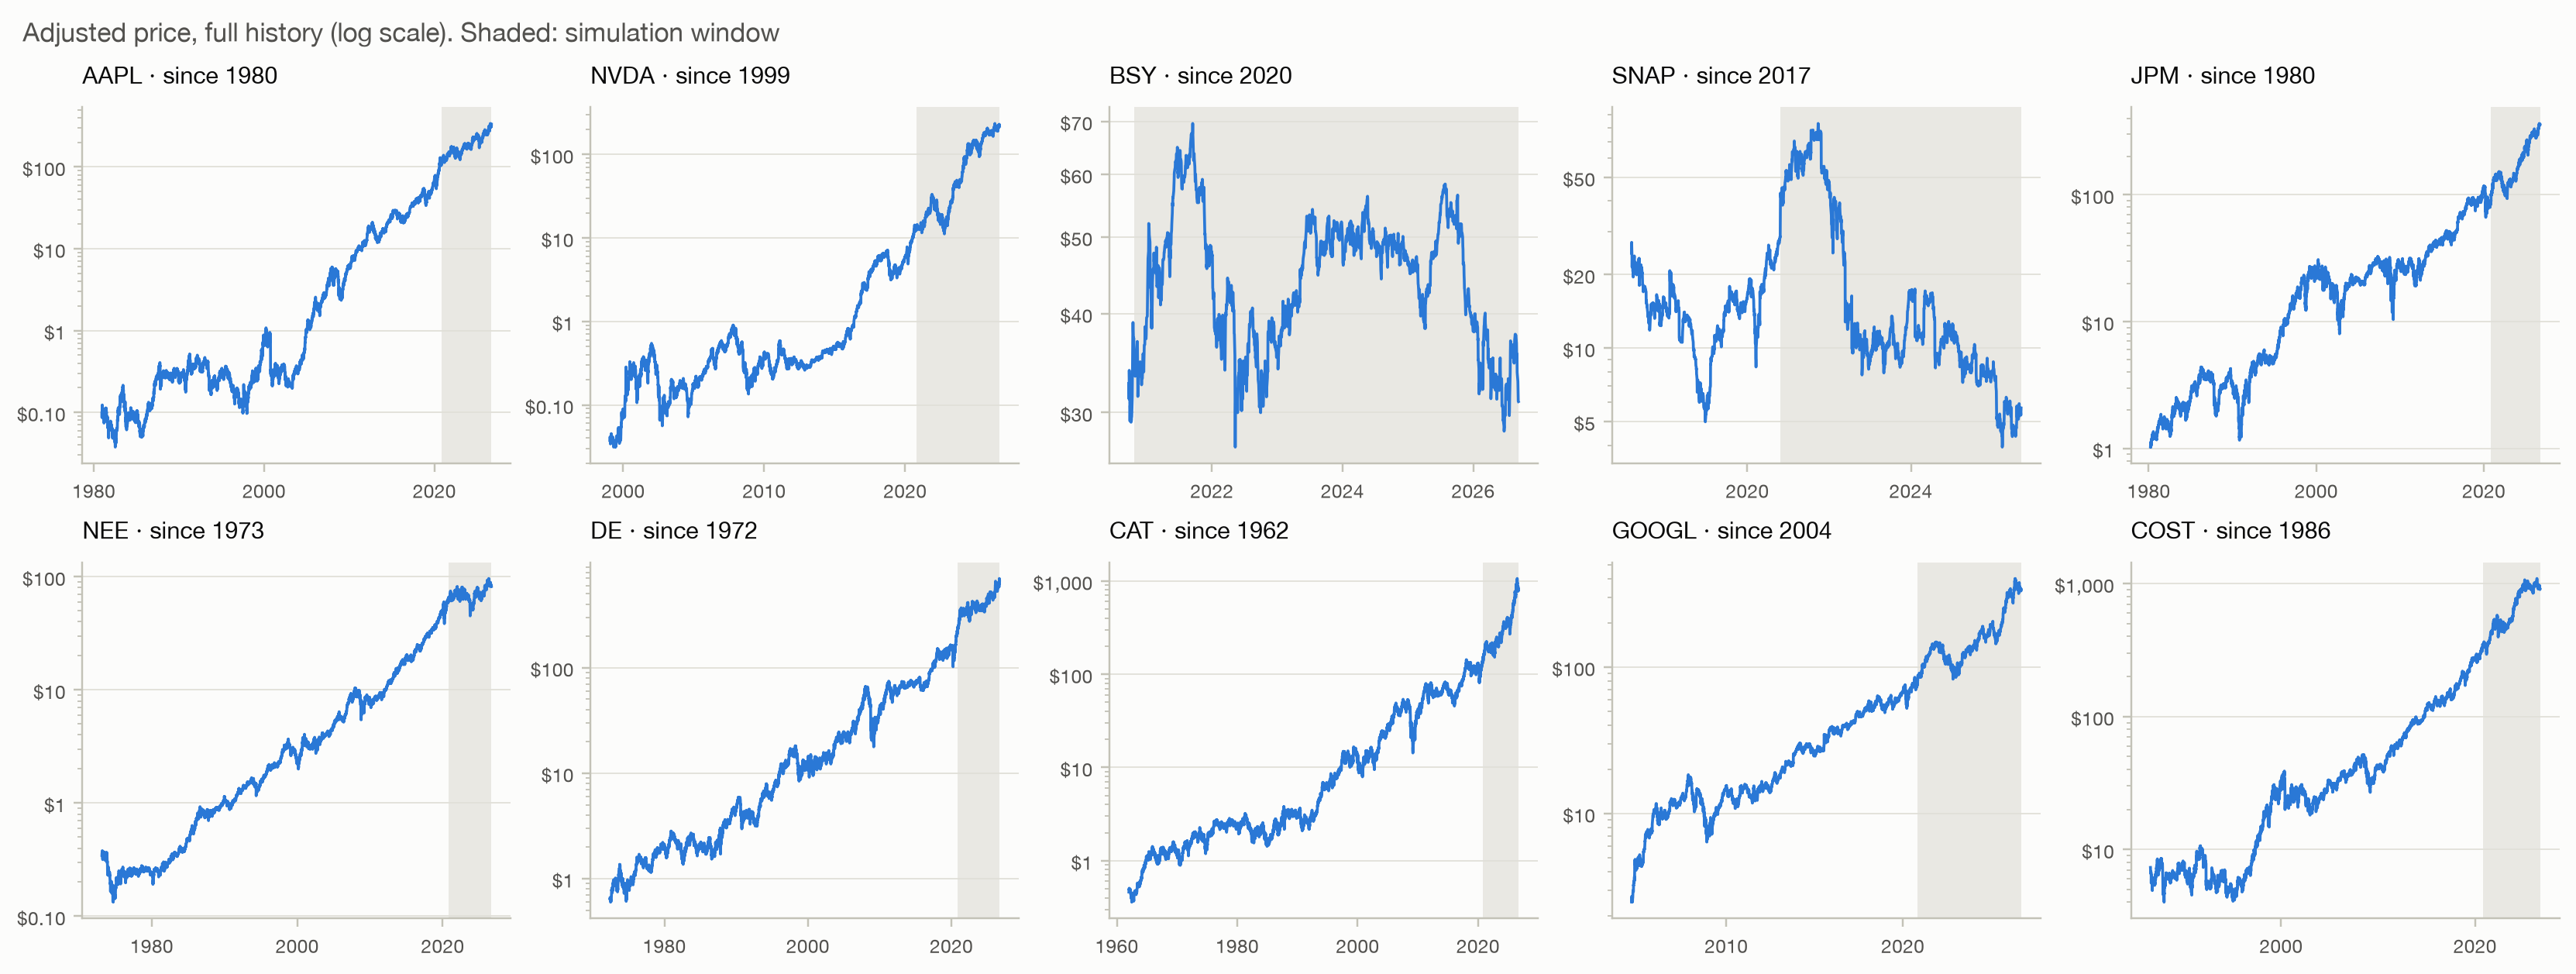

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 5.6), constrained_layout=True)
dollars = FuncFormatter(lambda v, _: f"${v:,.0f}" if v >= 1 else f"${v:.2f}")
for ax, ticker in zip(axes.flat, TICKERS):
    series = prices_all[ticker].dropna()
    ax.axvspan(window_start, LAST_DATE, color=charts.INK["grid"], alpha=0.7, linewidth=0, zorder=0)
    ax.plot(series.index, series, color=charts.COLORS["blue"], linewidth=1.2)
    ax.set_yscale("log")
    decades = np.log10(series.max() / series.min())
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0,) if decades > 2 else (1.0, 2.0, 5.0)))
    ax.yaxis.set_major_formatter(dollars)
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=3, maxticks=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(labelsize=8)
    ax.set_title(f"{ticker} · since {series.index[0]:%Y}", fontsize=10)
fig.suptitle("Adjusted price, full history (log scale). Shaded: simulation window",
             x=0.005, ha="left", fontsize=11, color=charts.INK["secondary"])
plt.show()

### How closely the stocks move together
**How to read this chart:** each cell is the correlation of daily returns between two stocks. Darker red means they move more alike. Blue would mean they tend to move in opposite directions; no pair here does.

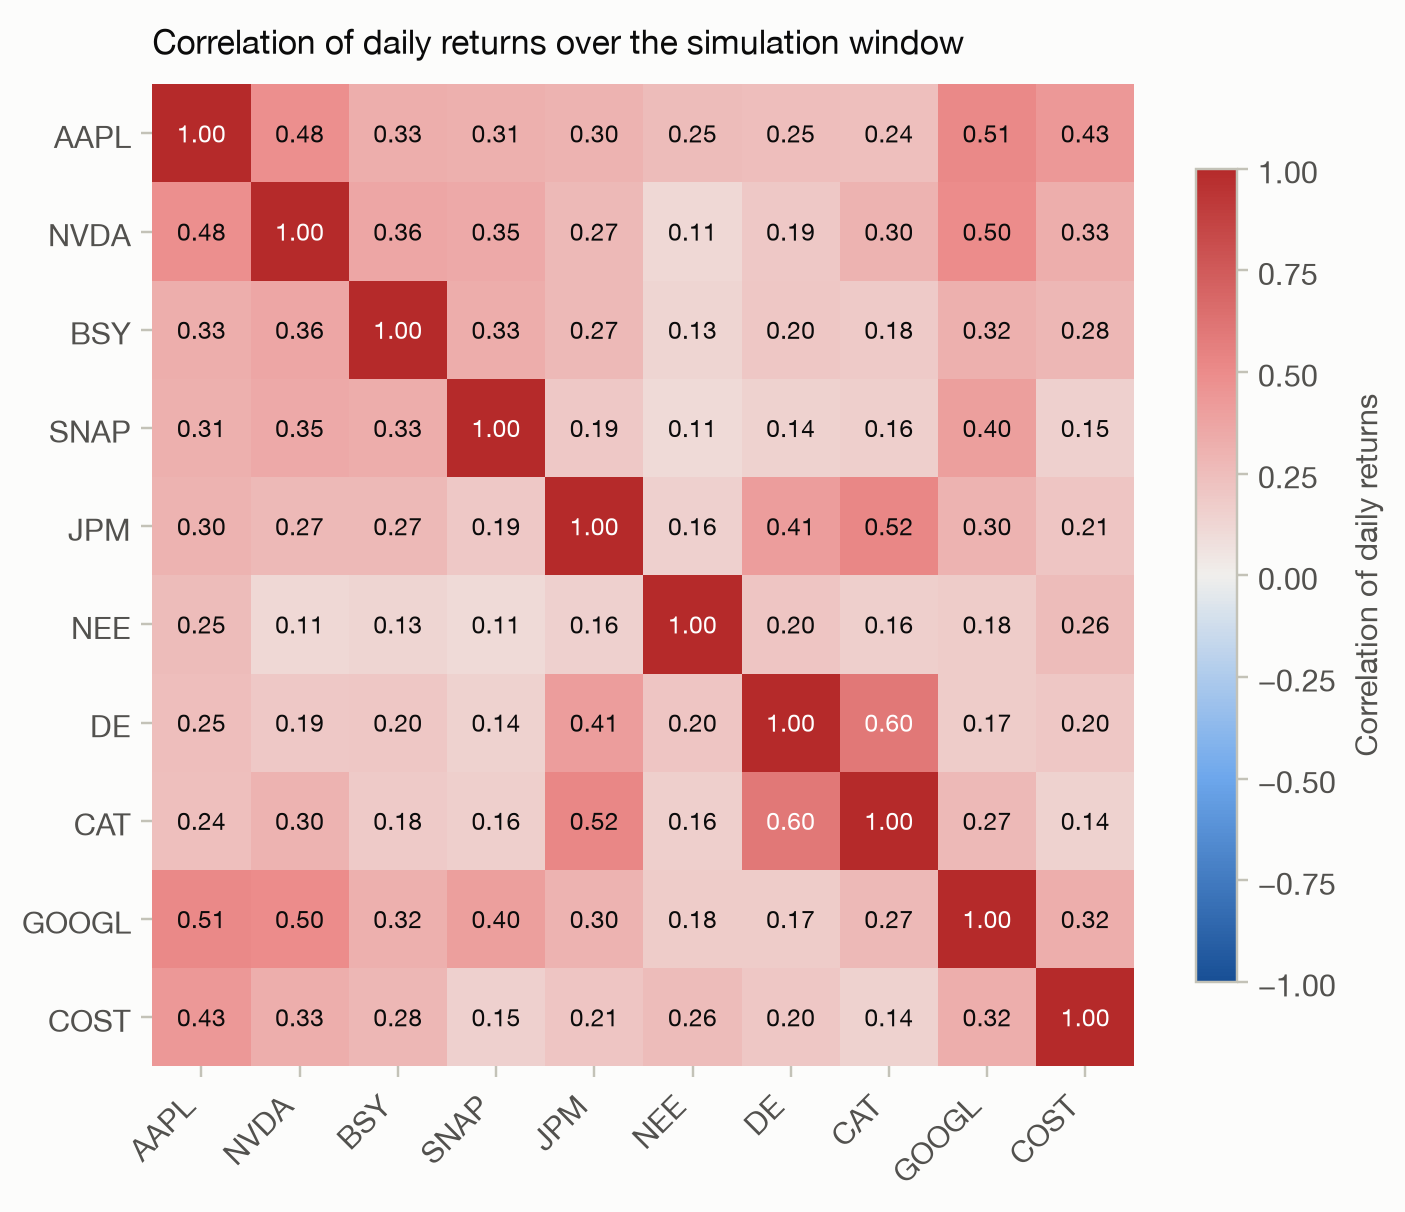

In [6]:
corr = stats.log_returns(prices.reindex(columns=TICKERS)).dropna().corr()
fig, ax = plt.subplots(figsize=(7.2, 6))
image = ax.imshow(corr, cmap=charts.CORR_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(N), TICKERS, rotation=45, ha="right")
ax.set_yticks(range(N), TICKERS)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
for i in range(N):
    for j in range(N):
        value = float(corr.to_numpy()[i, j])
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(value) > 0.6 else charts.INK["primary"])
fig.colorbar(image, ax=ax, shrink=0.8, label="Correlation of daily returns")
ax.set_title("Correlation of daily returns over the simulation window")
plt.show()

### Earnings reports during the competition
Earnings days bring the biggest single-day moves. The simulation samples real history, which includes about four earnings seasons a year, so these jumps are already built in. This table is for information.

In [7]:
earnings = data.next_earnings(TICKERS, START, END)
display(earnings.style.format(
    {"next_earnings": lambda d: f"{d:%Y-%m-%d}" if isinstance(d, pd.Timestamp) else "unknown"}
))

,next_earnings,in_competition_window
ticker,,
AAPL,2026-10-29,True
NVDA,2026-11-17,True
BSY,2026-11-04,True
SNAP,2026-11-04,True
JPM,2026-10-13,True
NEE,2026-10-27,True
DE,2026-11-25,True
CAT,2026-10-29,True
GOOGL,2026-10-28,True


## 4. Simulating 3-month returns

**Block bootstrap.** Each simulated 3-month future is stitched together from random **1-month chunks of real history**. All stocks (ours, the rivals' and SPY) are drawn on the **same dates**, so real correlations, crashes and earnings seasons carry over. One-month chunks also keep the tendency of prices to partly reverse within a few weeks; shorter 10-day chunks overstated 3-month volatility by about 17% for SPY.

**Expected returns.** A stock's average past return is a poor forecast; used directly, the model would just pick recent winners. So the simulations are shifted to match several *views* of expected return. Volatility and correlations are the same in every view.

| View | Expected return per stock |
|---|---|
| **Neutral (CAPM)** | T-bill rate + beta × 5% equity premium. Only risk separates the stocks. |
| **Momentum** | Neutral + 4% a year per standard deviation of momentum |
| **Analyst targets** | Neutral + 25% of the upside to the analyst price target, relative to the median stock |
| **Historical trend** | No shift: each stock keeps its average return over the window (the optimistic "trend continues" case) |

The final choice averages over all four views, so it doesn't depend on any single forecast.

In [8]:
analyst_targets = data.load_analyst_targets(TICKERS + RIVALS_KEPT, refresh=REFRESH_DATA)
targets, target_details = scenarios.drift_scenarios(prices, prices.columns, BENCHMARK, SETTINGS, RISK_FREE,
                                                    analyst_targets, ANALYST_SHRINK)
if VIEW_WEIGHTS.get("analyst") and "analyst" not in targets.columns:
    print("Too few analyst targets available today: the analyst view is skipped.")

VIEWS = [v for v, weight in VIEW_WEIGHTS.items() if weight > 0 and (v == "trend" or v in targets.columns)]
VIEW_SHARE = pd.Series({v: float(VIEW_WEIGHTS[v]) for v in VIEWS})
VIEW_SHARE /= VIEW_SHARE.sum()
LOG_RETURNS = np.diff(np.log(prices.to_numpy()), axis=0)


def simulate(n_sims, seed):
    """Simulated returns of our stocks plus the benchmark (last column) per view, and each view's rival field."""
    generator = np.random.default_rng(seed)
    totals, expected = scenarios.bootstrap_log_returns(LOG_RETURNS, HORIZON, n_sims, BLOCK_DAYS, generator,
                                                       SETTINGS.half_life_days)
    returns_by_view, fields = {}, {}
    for v in VIEWS:
        all_returns = scenarios.apply_view(totals, expected, targets[v].to_numpy() if v in targets else None)
        # The same rivals (same seed) in every view: views differ only in expected returns.
        fields[v] = rivals.rival_field(all_returns[:, :N_POOL], N_RIVALS, seed + 1, N, MIN_WEIGHT, MAX_WEIGHT)
        returns_by_view[v] = np.hstack([all_returns[:, :N], all_returns[:, -1:]])
    return returns_by_view, fields


screen_returns, screen_fields = simulate(N_SIMS_SCREEN, SEED)

expected_returns = pd.DataFrame(
    {VIEW_LABELS[v]: screen_returns[v].mean(axis=0, dtype=np.float64) for v in VIEWS}, index=TICKERS + [BENCHMARK]
)
inputs = target_details.loc[TICKERS + [BENCHMARK], [c for c in ("beta", "momentum_12_1", "analyst_upside")
                                                    if c in target_details]]
display(inputs.join(expected_returns).style
        .set_caption(f"Inputs, and the expected return over the {HORIZON}-day competition in each view")
        .format("{:.1%}", na_rep="–").format("{:.2f}", subset=pd.Index(["beta"])))

,beta,momentum_12_1,analyst_upside,Neutral (CAPM),Momentum,Analyst targets,Historical trend
AAPL,1.16,33.8%,-2.0%,2.4%,2.4%,1.2%,5.5%
NVDA,2.00,26.5%,49.9%,3.4%,3.3%,5.2%,16.6%
BSY,1.12,-31.7%,43.6%,2.3%,1.5%,3.9%,1.7%
SNAP,1.60,-26.2%,30.0%,2.9%,2.2%,3.6%,-3.2%
JPM,1.01,23.8%,5.6%,2.2%,2.1%,1.5%,6.9%
NEE,0.58,23.3%,19.5%,1.7%,1.6%,1.8%,2.2%
DE,0.87,33.1%,1.9%,2.0%,2.0%,1.1%,5.7%
CAT,1.01,104.1%,19.2%,2.2%,3.0%,2.3%,9.0%
GOOGL,1.21,43.9%,26.5%,2.4%,2.6%,3.0%,7.5%
COST,0.75,-0.1%,18.5%,1.9%,1.5%,2.0%,5.2%


**How to read this table:** the first columns are the inputs behind each view; the rest are the expected returns over the whole competition, not per year. Under the neutral view, NVDA and SNAP expect more because their high beta means more market risk.

### Sanity checks
1. **Volatility:** simulated 64-day volatility should be close to that of real historical 64-day periods. The historical figure is itself uncertain by about ±15% (six years hold only about 23 separate 3-month periods), so the check only flags gaps above 25%.
2. **Means:** simulated mean returns must equal each view's targets (true by construction, so this checks the code).
3. **Fairness:** if "we" are just one more random rival, P(win) must be about 1 / (rivals + 1). This checks the win-counting code.

In [9]:
hist_vol = stats.log_returns(prices.reindex(columns=TICKERS + [BENCHMARK]), HORIZON).std()
sim_vol = pd.Series(np.log1p(screen_returns[VIEWS[0]]).std(axis=0), index=TICKERS + [BENCHMARK])
vol_check = pd.DataFrame({"historical": hist_vol, "simulated": sim_vol, "ratio": sim_vol / hist_vol})
display(vol_check.style.set_caption(f"{HORIZON}-day log-return volatility")
        .format({"historical": "{:.1%}", "simulated": "{:.1%}", "ratio": "{:.2f}"}))
benchmark_ratio = float(sim_vol[BENCHMARK] / hist_vol[BENCHMARK])
assert 0.75 <= benchmark_ratio <= 1.25, "Simulated SPY volatility is off by more than 25%"

mean_gap = max(
    np.abs(screen_returns[v].mean(axis=0, dtype=np.float64) - targets[v].loc[TICKERS + [BENCHMARK]].to_numpy()).max()
    for v in VIEWS if v in targets.columns
)
print(f"Largest gap between simulated and target mean return: {mean_gap:.1e}")
assert mean_gap < 1e-4

check_totals, check_expected = scenarios.bootstrap_log_returns(LOG_RETURNS, HORIZON, 50_000, BLOCK_DAYS,
                                                               np.random.default_rng(SEED + 99))
check_returns = scenarios.apply_view(check_totals, check_expected, targets["neutral"].to_numpy())
every_rival = rivals.rival_returns(check_returns[:, :N_POOL], N_RIVALS + 1, SEED + 99, N, MIN_WEIGHT, MAX_WEIGHT)
p_self = (every_rival[:, 0] > every_rival[:, 1:].max(axis=1)).mean()
print(f"P(win) of a random rival against {N_RIVALS} others: {p_self:.2%} (should be about {1 / (N_RIVALS + 1):.2%})")
assert abs(p_self - 1 / (N_RIVALS + 1)) < 0.006

,historical,simulated,ratio
AAPL,11.6%,12.8%,1.10
NVDA,24.5%,24.2%,0.99
BSY,16.7%,17.9%,1.07
SNAP,32.8%,34.4%,1.05
JPM,10.9%,11.6%,1.07
NEE,11.1%,13.5%,1.22
DE,12.3%,13.2%,1.08
CAT,15.6%,15.7%,1.01
GOOGL,14.8%,14.4%,0.97
COST,9.5%,11.8%,1.25


Largest gap between simulated and target mean return: 3.4e-09


P(win) of a random rival against 20 others: 4.63% (should be about 4.76%)


**Result:** simulated volatility is close to history for most stocks, means match exactly, and a random rival wins about 1 time in 21, as it should.

## 5. The simulated rivals

Each simulated future contains **20 rivals**. Every rival holds 10 random stocks from a pool of about 100 popular names, with random weights under the same 5–20% rules. Rivals live in the same simulated market as us: when the market crashes in one future, it crashes for everyone.

The number that matters is the **winning rival's return**: to win, our portfolio has to beat it.

,winning rival: 10th pct,winning rival: median,winning rival: 90th pct,3rd-best rival: median
Neutral (CAPM),-0.5%,12.8%,30.2%,8.3%
Momentum,-0.6%,12.8%,30.3%,8.2%
Analyst targets,-0.4%,12.9%,30.4%,8.4%
Historical trend,2.7%,16.9%,35.8%,11.9%


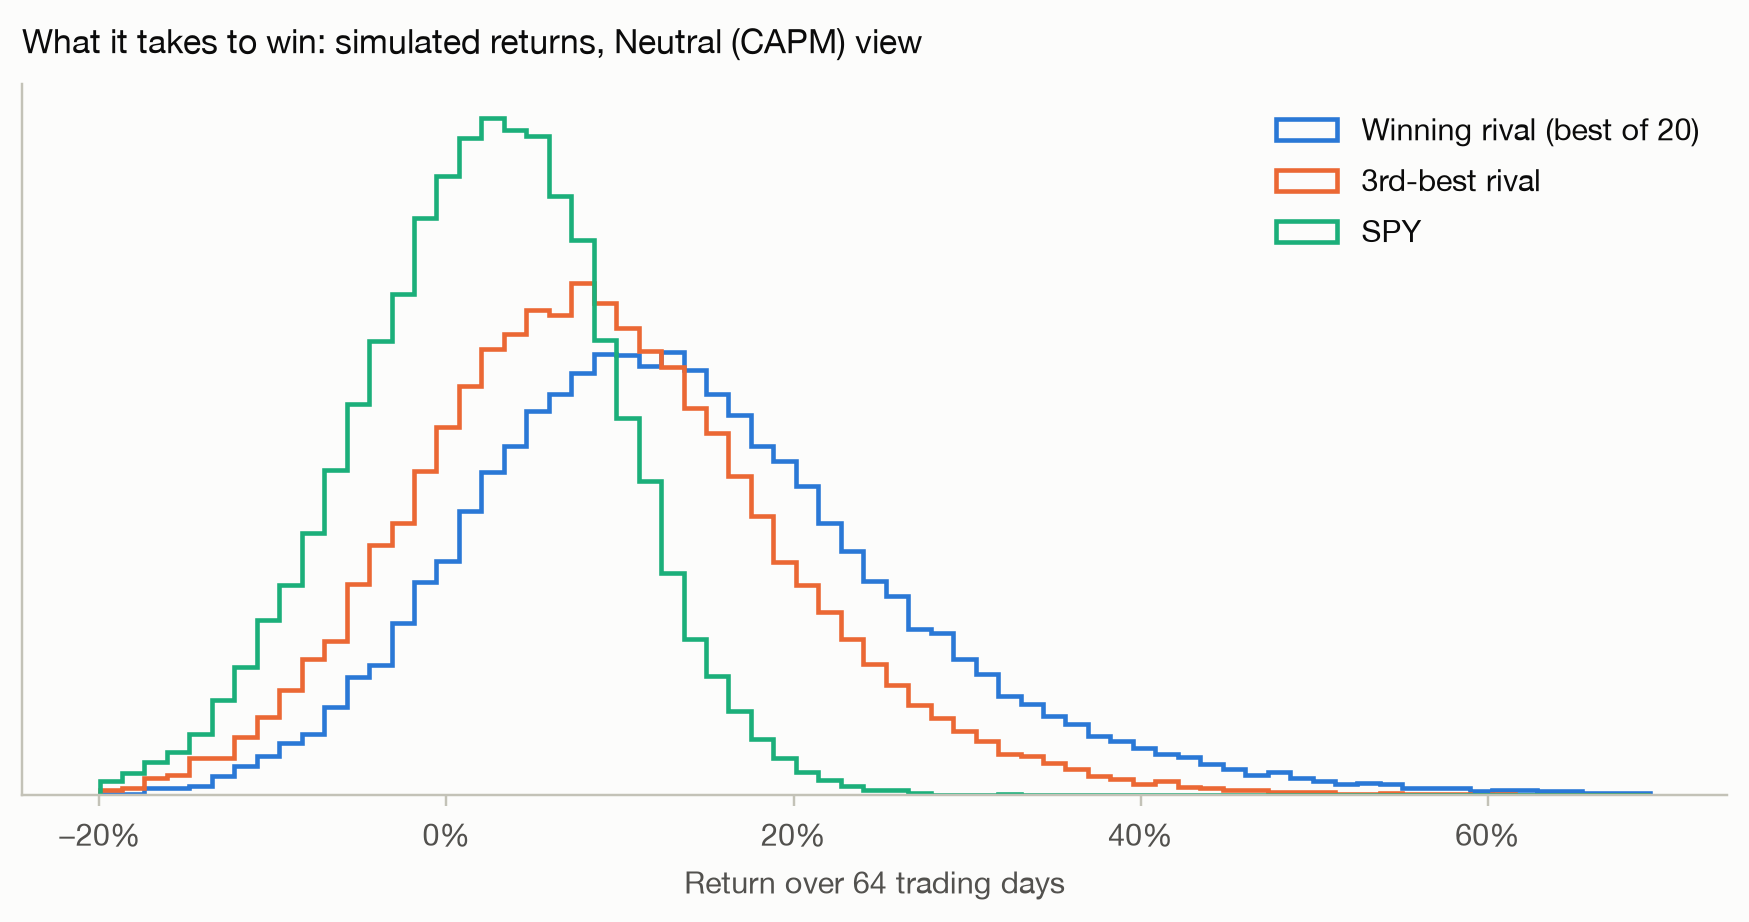

In [10]:
field_table = pd.DataFrame({
    VIEW_LABELS[v]: {
        "winning rival: 10th pct": np.percentile(best, 10),
        "winning rival: median": np.median(best),
        "winning rival: 90th pct": np.percentile(best, 90),
        "3rd-best rival: median": np.median(third),
    }
    for v, (best, third) in screen_fields.items()
}).T
display(field_table.style.set_caption(f"Returns over {HORIZON} trading days").format("{:.1%}"))

best, third = screen_fields[VIEWS[0]]
spy_returns = screen_returns[VIEWS[0]][:, N]
series_list = (best, third, spy_returns)
low, high = min(np.percentile(s, 0.2) for s in series_list), max(np.percentile(s, 99.8) for s in series_list)
bins = np.linspace(low, high, 70)
fig, ax = plt.subplots(figsize=(10, 4.2))
for values, label, color in [(best, "Winning rival (best of 20)", charts.COLORS["blue"]),
                             (third, "3rd-best rival", charts.COLORS["orange"]),
                             (spy_returns, BENCHMARK, charts.COLORS["aqua"])]:
    ax.hist(values, bins=bins, histtype="step", linewidth=1.5, color=color, label=label, density=True)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_yticks([])
ax.set_xlabel(f"Return over {HORIZON} trading days")
ax.legend(loc="upper right")
ax.set_title(f"What it takes to win: simulated returns, {VIEW_LABELS[VIEWS[0]]} view")
plt.show()

**How to read this chart:** each line is a distribution over simulated futures; higher means more likely. The market (SPY) typically returns a few percent in 3 months, but the *best of 20 rivals* typically returns over 10%. A portfolio that merely tracks the market would almost never win.

## 6. Searching all 5.3 million allowed portfolios

On a 2.5% grid, the rules (10 stocks, 5–20% each, summing to 100%) allow exactly **5,266,030** portfolios. All of them are scored; there's no optimizer that could get stuck.

- **Stage 1 (screen):** every portfolio against 50,000 simulated futures in each view, on all CPU cores in parallel. The best 20,000 in each view move on.
- **Stage 2 (confirm):** the candidates are re-scored on **1,000,000 fresh futures**. Out of 5 million scores, the top ones are partly luck; fresh simulations remove that bias.
- The best candidate by P(win), averaged across views, is the grid pick.

In [11]:
units = search.enumerate_grid(N, MIN_WEIGHT, MAX_WEIGHT, GRID_STEP)
free_units = round((1 - N * MIN_WEIGHT) / GRID_STEP)
assert (units.sum(axis=1) == free_units).all(), "weights must sum to 100%"
assert units.max() * GRID_STEP <= MAX_WEIGHT - MIN_WEIGHT + 1e-9, "weights must stay within the limits"
if (N, MIN_WEIGHT, MAX_WEIGHT, GRID_STEP) == (10, 0.05, 0.20, 0.025):
    assert len(units) == 5_266_030
print(f"{len(units):,} allowed portfolios on a {GRID_STEP:.1%} grid")

cache_params = {"tickers": TICKERS, "pool": RIVALS_KEPT, "last_date": LAST_DATE, "window_start": window_start,
                "settings": SETTINGS, "grid_step": GRID_STEP, "n_sims": N_SIMS_SCREEN, "seed": SEED}
screen = {}
for view in VIEWS:
    print(f"Stage 1 · {VIEW_LABELS[view]}")
    view_targets = targets[view].round(10).tolist() if view in targets.columns else None
    counts = cache.cached_npz(f"screen_{view}", cache.cache_key(view=view, targets=view_targets, **cache_params),
                              search.score_portfolios, units, MIN_WEIGHT, GRID_STEP, screen_returns[view][:, :N],
                              *screen_fields[view])
    screen[view] = {k: counts[k].astype(np.float32) / N_SIMS_SCREEN for k in ("win", "top3", "loss")}

5,266,030 allowed portfolios on a 2.5% grid
Stage 1 · Neutral (CAPM)
  loaded cached results (screen_neutral_55d43e96c623.npz)
Stage 1 · Momentum
  loaded cached results (screen_momentum_399728ba01c2.npz)
Stage 1 · Analyst targets
  loaded cached results (screen_analyst_dbd21f0cf100.npz)
Stage 1 · Historical trend
  loaded cached results (screen_trend_8a6675b7bf4e.npz)


In [12]:
mu = np.stack([screen_returns[v][:, :N].mean(axis=0, dtype=np.float64) for v in VIEWS])
cov = np.cov(screen_returns[VIEWS[0]][:, :N], rowvar=False)
means, stds = search.portfolio_moments(units, MIN_WEIGHT, GRID_STEP, mu, cov)
avg_mean = means @ VIEW_SHARE.to_numpy(np.float32)
stage1_win = VIEW_SHARE.to_numpy(np.float32) @ np.stack([screen[v]["win"] for v in VIEWS])
stage1_loss = VIEW_SHARE.to_numpy(np.float32) @ np.stack([screen[v]["loss"] for v in VIEWS])

EQUAL = int(np.flatnonzero((units == free_units // N).all(axis=1))[0])
MAX_MEAN = int(np.argmax(avg_mean))
MAX_SHARPE = int(np.argmax((avg_mean - RISK_FREE_HORIZON) / stds))

candidate_set = {EQUAL, MAX_MEAN, MAX_SHARPE}
for view in VIEWS:
    candidate_set.update(np.argpartition(-screen[view]["win"], TOP_K_CONFIRM)[:TOP_K_CONFIRM].tolist())
candidates = np.array(sorted(candidate_set))
print(f"{len(candidates):,} candidates carried into stage 2")

confirm_returns, confirm_fields = simulate(N_SIMS_CONFIRM, SEED + 1)
candidate_weights = search.weights_from_units(units[candidates], MIN_WEIGHT, GRID_STEP)
confirm = {view: search.evaluate_weights(candidate_weights, confirm_returns[view][:, :N],
                                         *confirm_fields[view]).set_index(candidates)
           for view in VIEWS}
robust = pd.DataFrame({v: confirm[v]["p_win"] for v in VIEWS}).mul(VIEW_SHARE).sum(axis=1)
GRID_PICK = int(candidates[int(np.argmax(robust.to_numpy()))])
grid_pick_weights = search.weights_from_units(units[GRID_PICK], MIN_WEIGHT, GRID_STEP)
print(f"Grid pick: {search.holdings_label(grid_pick_weights, TICKERS, MIN_WEIGHT)}"
      f" · P(win) {robust[GRID_PICK]:.2%} averaged across views")

35,485 candidates carried into stage 2


Grid pick: NVDA 20% · SNAP 20% · GOOGL 20% · BSY 10% · P(win) 11.27% averaged across views


### Top 10 portfolios on the grid
Weights, P(win) averaged across views, and P(win) with its rank in each view. A portfolio that ranks near the top in every view doesn't depend on one particular forecast.

In [13]:
top = robust.sort_values(ascending=False).index[:10]
top_table = pd.DataFrame(search.weights_from_units(units[top], MIN_WEIGHT, GRID_STEP), columns=TICKERS,
                         index=range(1, 11))
top_table["P(win) avg"] = robust.loc[top].to_numpy()
for view in VIEWS:
    top_table[f"P(win) {VIEW_LABELS[view]}"] = confirm[view].loc[top, "p_win"].to_numpy()
    top_table[f"rank {VIEW_LABELS[view]}"] = (confirm[view]["p_win"].rank(ascending=False, method="min")
                                              .loc[top].astype(int).to_numpy())
probability_columns = pd.Index(["P(win) avg"] + [f"P(win) {VIEW_LABELS[v]}" for v in VIEWS])
display(top_table.style
        .background_gradient(cmap="Blues", subset=pd.Index(TICKERS), vmin=MIN_WEIGHT, vmax=MAX_WEIGHT + 0.05)
        .format("{:.1%}", subset=pd.Index(TICKERS)).format("{:.2%}", subset=probability_columns))

stage_check = pd.DataFrame({
    VIEW_LABELS[v]: {"stage 1": screen[v]["win"][top].mean(), "stage 2": confirm[v].loc[top, "p_win"].mean()}
    for v in VIEWS
}).T
stage_check["gap"] = stage_check["stage 1"] - stage_check["stage 2"]
display(stage_check.style.set_caption("Average P(win) of the top 10: stage 1 screen vs. fresh stage 2 simulations")
        .format("{:.2%}"))
if stage_check["gap"].abs().max() > 0.01:
    print("Note: stage 1 and stage 2 differ by more than 1 point; consider raising N_SIMS_SCREEN.")

,AAPL,NVDA,BSY,SNAP,JPM,NEE,DE,CAT,GOOGL,COST,P(win) avg,P(win) Neutral (CAPM),rank Neutral (CAPM),P(win) Momentum,rank Momentum,P(win) Analyst targets,rank Analyst targets,P(win) Historical trend,rank Historical trend
1,5.0%,20.0%,10.0%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,5.0%,11.27%,11.25%,2,10.77%,1,12.55%,6,10.50%,15
2,10.0%,20.0%,5.0%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,5.0%,11.20%,11.13%,7,10.75%,2,12.11%,56,10.80%,1
3,7.5%,20.0%,7.5%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,5.0%,11.20%,11.16%,5,10.73%,3,12.30%,22,10.61%,8
4,5.0%,20.0%,7.5%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,7.5%,11.12%,11.07%,12,10.61%,7,12.27%,24,10.54%,11
5,7.5%,20.0%,5.0%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,7.5%,11.10%,11.02%,14,10.62%,6,12.06%,66,10.70%,2
6,5.0%,20.0%,12.5%,20.0%,5.0%,5.0%,5.0%,5.0%,17.5%,5.0%,11.09%,11.14%,6,10.62%,5,12.49%,8,10.11%,64
7,5.0%,20.0%,20.0%,20.0%,5.0%,5.0%,5.0%,5.0%,10.0%,5.0%,11.09%,11.34%,1,10.70%,4,12.86%,1,9.46%,563
8,5.0%,20.0%,5.0%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,10.0%,11.03%,10.93%,28,10.50%,19,12.05%,67,10.63%,6
9,5.0%,20.0%,7.5%,20.0%,5.0%,7.5%,5.0%,5.0%,20.0%,5.0%,11.03%,11.00%,18,10.56%,10,12.22%,30,10.32%,28
10,5.0%,20.0%,7.5%,20.0%,7.5%,5.0%,5.0%,5.0%,20.0%,5.0%,11.02%,10.96%,22,10.53%,14,12.12%,55,10.47%,18


,stage 1,stage 2,gap
Neutral (CAPM),11.22%,11.10%,0.12%
Momentum,10.71%,10.64%,0.07%
Analyst targets,12.42%,12.30%,0.12%
Historical trend,10.39%,10.41%,-0.02%


**How to read the second table:** if stage 1 scores were much higher than stage 2, the screen would be picking lucky portfolios. Gaps of a fraction of a point mean the screen is reliable.

### The trade-off: chance of winning vs. chance of losing money
Each gray dot is one of 40,000 randomly sampled allowed portfolios (stage 1, averaged across views).

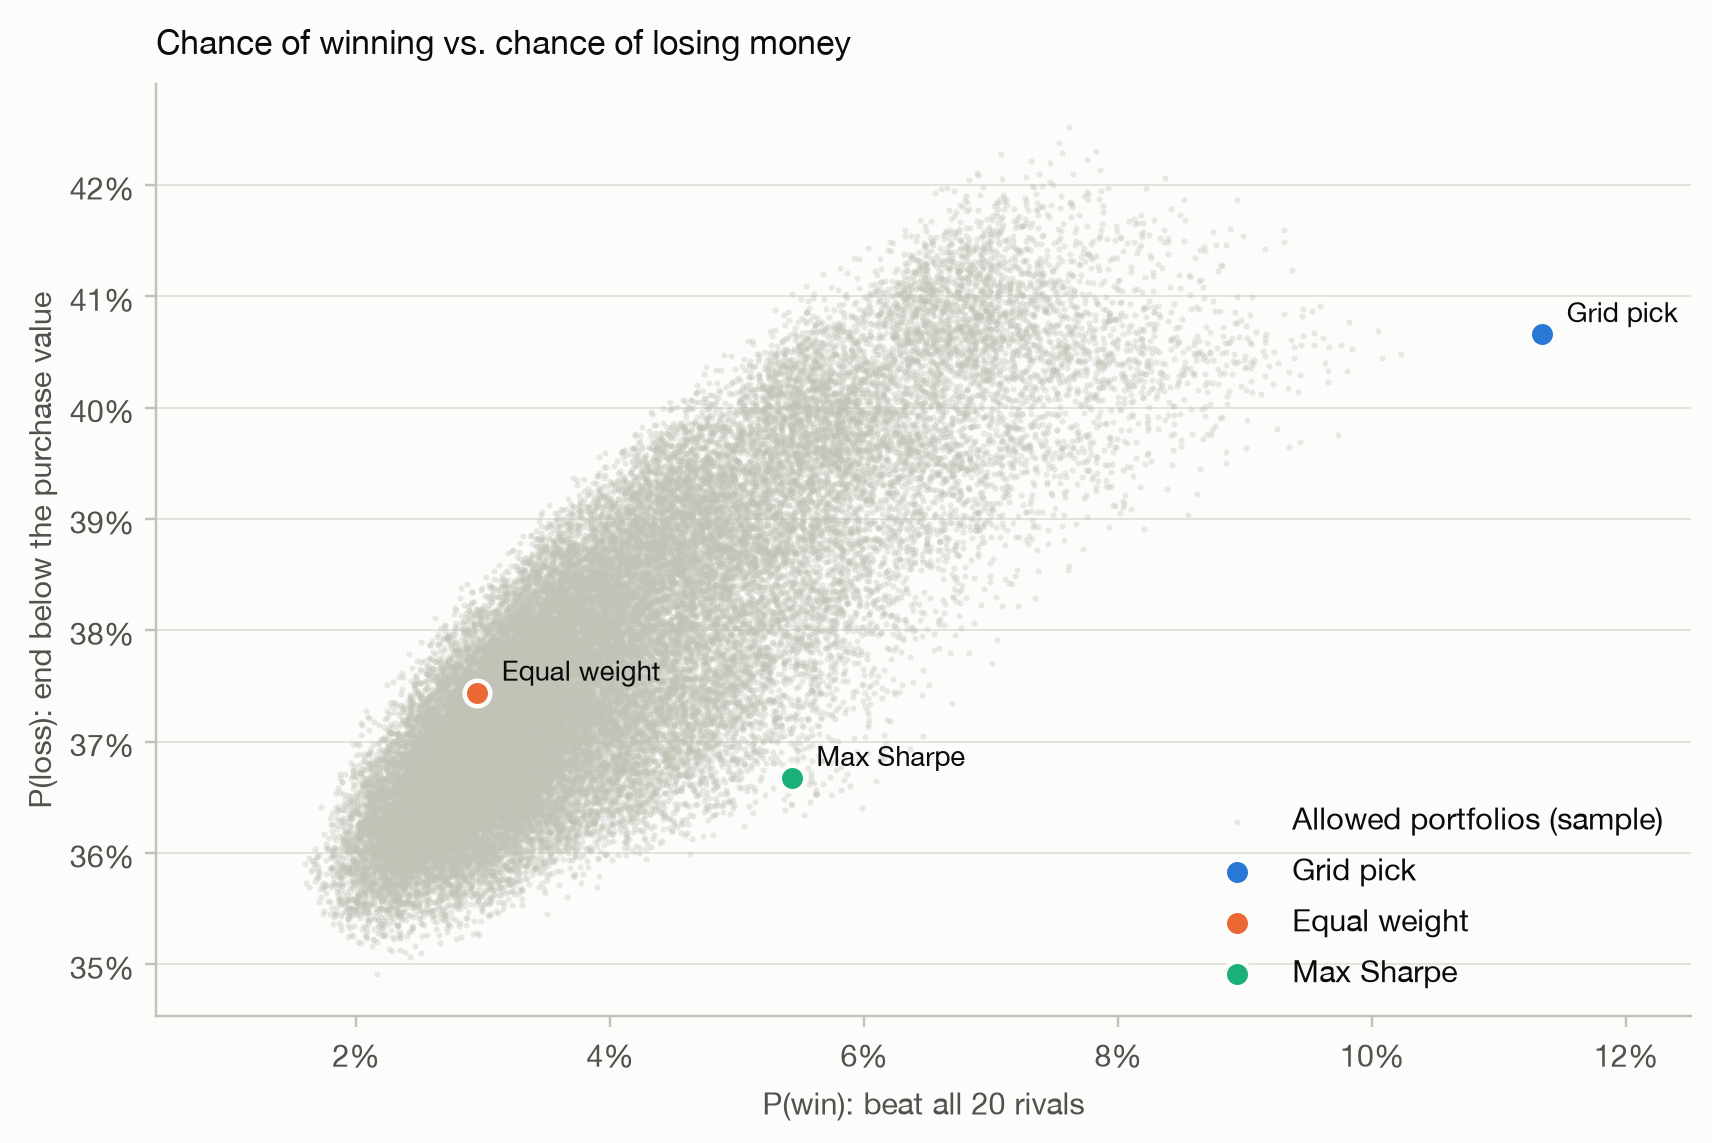

In [14]:
sample = np.random.default_rng(SEED).choice(len(units), 40_000, replace=False)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(stage1_win[sample], stage1_loss[sample], s=4, color=charts.INK["axis"], alpha=0.35, linewidths=0,
           label="Allowed portfolios (sample)")
for position, label, color in [(GRID_PICK, "Grid pick", charts.COLORS["blue"]),
                               (EQUAL, "Equal weight", charts.COLORS["orange"]),
                               (MAX_SHARPE, "Max Sharpe", charts.COLORS["aqua"])]:
    ax.scatter(stage1_win[position], stage1_loss[position], s=70, color=color, edgecolors=charts.INK["surface"],
               linewidths=1.5, zorder=3, label=label)
    ax.annotate(label, (stage1_win[position], stage1_loss[position]), xytext=(8, 4), textcoords="offset points",
                fontsize=9, color=charts.INK["primary"])
ax.margins(x=0.12)
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_xlabel("P(win): beat all 20 rivals")
ax.set_ylabel("P(loss): end below the purchase value")
ax.legend(loc="lower right")
ax.set_title("Chance of winning vs. chance of losing money")
charts.save_figure(fig, "win_vs_loss")
plt.show()

**How to read this chart:** further right means a better chance of finishing first; higher means a bigger chance of losing money. The best portfolios for winning sit at the far right, and they pay for it with a higher chance of a loss. Equal weight sits at the far left, and the textbook max-Sharpe portfolio lands in between.

## 7. Fine-tuning at 1% steps

The 2.5% grid is fairly coarse. Starting from the 25 best grid portfolios, the search now tries **moving 1% from any stock to any other**, keeps the best 25, and repeats until nothing improves (a *beam search*). Scores use the 1,000,000 stage 2 futures, averaged across views.

Tuning weights against one set of simulations can overfit its noise. So the grid pick and the fine-tuned pick are then compared on **another 1,000,000 fresh futures**, and the fine-tuned version is kept only if it holds up.

In [15]:
def robust_win_rate(weight_rows):
    """P(win) averaged across views on the stage 2 simulations."""
    return VIEW_SHARE.to_numpy() @ np.stack([search.win_rates(weight_rows, confirm_returns[v][:, :N],
                                                               confirm_fields[v][0]) for v in VIEWS])


start_weights = search.weights_from_units(units[robust.sort_values(ascending=False).index[:25]], MIN_WEIGHT, GRID_STEP)
fine_weights, fine_scores = search.refine_weights(start_weights, robust_win_rate, MIN_WEIGHT, MAX_WEIGHT, FINE_STEP)
print(f"Evaluated {len(fine_weights):,} fine-tuned portfolios")

validate_returns, validate_fields = simulate(N_SIMS_CONFIRM, SEED + 2)
finalists = {f"Grid pick ({GRID_STEP:.1%} steps)": grid_pick_weights,
             f"Fine-tuned ({FINE_STEP:.0%} steps)": fine_weights[0]}
validation = pd.DataFrame({
    name: {VIEW_LABELS[v]: search.win_rates(w[None, :], validate_returns[v][:, :N], validate_fields[v][0])[0]
           for v in VIEWS}
    for name, w in finalists.items()
}).T
validation["P(win) avg"] = validation[[VIEW_LABELS[v] for v in VIEWS]] @ VIEW_SHARE.to_numpy()
FINAL_NAME = str(validation["P(win) avg"].idxmax())
final_weights = np.asarray(finalists[FINAL_NAME], dtype=float)

display(pd.DataFrame(finalists, index=TICKERS).T.style.set_caption("Weights")
        .background_gradient(cmap="Blues", vmin=MIN_WEIGHT, vmax=MAX_WEIGHT + 0.05).format("{:.1%}"))
display(validation.style.set_caption("P(win) on fresh validation simulations").format("{:.2%}"))
print(f"Final choice: {FINAL_NAME} · {search.holdings_label(final_weights, TICKERS, MIN_WEIGHT)}")

  round 1: 797 new portfolios · best score 11.270%
Evaluated 822 fine-tuned portfolios


,AAPL,NVDA,BSY,SNAP,JPM,NEE,DE,CAT,GOOGL,COST
Grid pick (2.5% steps),5.0%,20.0%,10.0%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,5.0%
Fine-tuned (1% steps),5.0%,20.0%,10.0%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,5.0%


,Neutral (CAPM),Momentum,Analyst targets,Historical trend,P(win) avg
Grid pick (2.5% steps),11.24%,10.77%,12.53%,10.49%,11.26%
Fine-tuned (1% steps),11.24%,10.77%,12.53%,10.49%,11.26%


Final choice: Grid pick (2.5% steps) · NVDA 20% · SNAP 20% · GOOGL 20% · BSY 10%


**How to read this:** the difference between the two is usually a small fraction of a percentage point. Finer weights polish the answer; the big decision (which stocks get the most money) was already made on the grid.

## 8. Comparison with standard portfolios

All portfolios are evaluated on the fresh validation futures, averaged across views:
- **Final pick:** from section 7
- **Equal weight:** 10% in each stock, the "no opinion" choice
- **Max Sharpe:** the best return per unit of risk, the textbook choice
- **Max expected return:** the highest average return
- **SPY:** the S&P 500, for reference (not allowed in the competition)

In [16]:
contenders = {
    "Final pick": final_weights,
    "Equal weight": search.weights_from_units(units[EQUAL], MIN_WEIGHT, GRID_STEP),
    "Max Sharpe": search.weights_from_units(units[MAX_SHARPE], MIN_WEIGHT, GRID_STEP),
    "Max expected return": search.weights_from_units(units[MAX_MEAN], MIN_WEIGHT, GRID_STEP),
}


def returns_of(contender, v):
    """Simulated returns of a contender (or the benchmark) in one view."""
    if contender == BENCHMARK:
        return validate_returns[v][:, N]
    return validate_returns[v][:, :N] @ np.asarray(contenders[contender], dtype=np.float32)


comparison_rows, pooled = {}, {}
for name in list(contenders) + [BENCHMARK]:
    per_view = {v: returns_of(name, v) for v in VIEWS}
    q05, q50, q95 = search.weighted_quantiles([per_view[v] for v in VIEWS], VIEW_SHARE.tolist(), [0.05, 0.5, 0.95])
    comparison_rows[name] = {
        "P(win)": sum(VIEW_SHARE[v] * (per_view[v] > validate_fields[v][0]).mean() for v in VIEWS),
        "P(top 3)": sum(VIEW_SHARE[v] * (per_view[v] > validate_fields[v][1]).mean() for v in VIEWS),
        "P(loss)": sum(VIEW_SHARE[v] * (per_view[v] < 0).mean() for v in VIEWS),
        "mean": sum(VIEW_SHARE[v] * per_view[v].mean(dtype=np.float64) for v in VIEWS),
        "5th pct": q05, "median": q50, "95th pct": q95,
    }
    pooled[name] = np.concatenate([per_view[v] for v in VIEWS])
comparison = pd.DataFrame(comparison_rows).T
display(comparison.style.set_caption(f"Return over {HORIZON} trading days, all views").format("{:.1%}"))
display(pd.DataFrame(contenders, index=TICKERS).T.style.set_caption("Weights")
        .background_gradient(cmap="Blues", vmin=MIN_WEIGHT, vmax=MAX_WEIGHT + 0.05).format("{:.1%}"))

,P(win),P(top 3),P(loss),mean,5th pct,median,95th pct
Final pick,11.3%,23.4%,40.7%,3.6%,-18.6%,3.2%,26.9%
Equal weight,3.0%,11.7%,37.4%,3.2%,-14.0%,3.3%,20.1%
Max Sharpe,5.6%,17.8%,36.7%,4.0%,-14.8%,3.8%,23.2%
Max expected return,6.4%,19.0%,36.8%,4.0%,-15.0%,3.9%,23.5%
SPY,0.4%,3.8%,35.0%,2.7%,-10.0%,2.9%,14.7%


,AAPL,NVDA,BSY,SNAP,JPM,NEE,DE,CAT,GOOGL,COST
Final pick,5.0%,20.0%,10.0%,20.0%,5.0%,5.0%,5.0%,5.0%,20.0%,5.0%
Equal weight,10.0%,10.0%,10.0%,10.0%,10.0%,10.0%,10.0%,10.0%,10.0%,10.0%
Max Sharpe,5.0%,20.0%,5.0%,5.0%,15.0%,5.0%,5.0%,20.0%,15.0%,5.0%
Max expected return,5.0%,20.0%,5.0%,5.0%,10.0%,5.0%,5.0%,20.0%,20.0%,5.0%


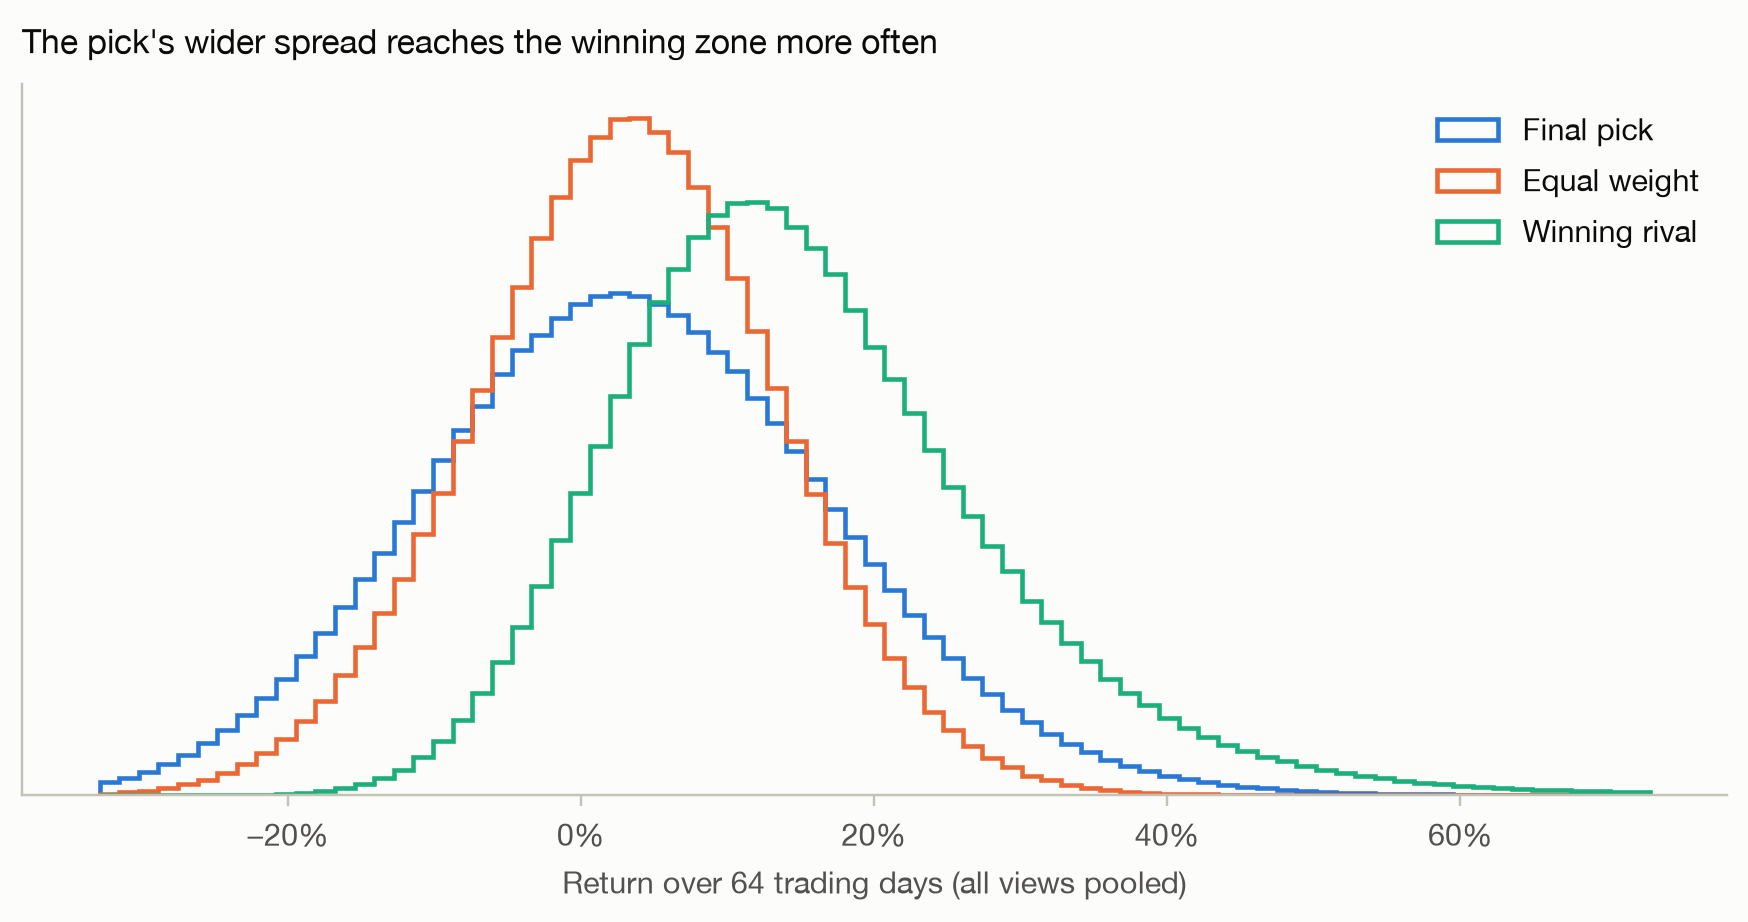

In [17]:
winning_rival = np.concatenate([validate_fields[v][0] for v in VIEWS])
series_list = (pooled["Final pick"], pooled["Equal weight"], winning_rival)
low, high = min(np.percentile(s, 0.2) for s in series_list), max(np.percentile(s, 99.8) for s in series_list)
bins = np.linspace(low, high, 80)
fig, ax = plt.subplots(figsize=(10, 4.2))
for values, label, color in [(pooled["Final pick"], "Final pick", charts.COLORS["blue"]),
                             (pooled["Equal weight"], "Equal weight", charts.COLORS["orange"]),
                             (winning_rival, "Winning rival", charts.COLORS["aqua"])]:
    ax.hist(values, bins=bins, histtype="step", linewidth=1.5, color=color, label=label, density=True)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_yticks([])
ax.set_xlabel(f"Return over {HORIZON} trading days (all views pooled)")
ax.legend(loc="upper right")
ax.set_title("The pick's wider spread reaches the winning zone more often")
charts.save_figure(fig, "winning_zone")
plt.show()

**How to read this chart:** the final pick (blue) and equal weight (orange) have about the same *typical* return, but the pick's distribution is wider. Its right tail reaches the returns that win the contest (aqua) much more often. The price is a fatter left tail: bigger losses are more likely too.

## 9. Backtest on past quarters

Would this method have worked before? For each past quarter (starting around the 14th of March, June, September and December), the search is re-run using **only data available on that date**: the neutral and momentum views (old analyst targets aren't available) on the full 2.5% grid. The pick is then scored on what actually happened over the next 64 trading days:
- **Percentile:** its rank among all 5.3 million allowed portfolios' actual returns (50% = average, 100% = best possible)
- **Field win rate:** the share of 20,000 random fields of 20 rivals, valued at their *actual* returns, that it beat

Two limits to keep in mind: about 18 quarters is a small sample, and the rival pool uses today's popular stocks, some of which soared, so the historical field is tougher than it looked at the time.

In [18]:
backtest_key = cache.cache_key(pool=RIVALS_KEPT, last_date=LAST_DATE, window_start=window_start, settings=SETTINGS,
                               grid_step=BACKTEST_GRID_STEP, n_sims=BACKTEST_SIMS, seed=SEED)
history_test = cache.cached_frame("backtest", backtest_key, backtest.walk_forward, prices, TICKERS, RIVALS_KEPT,
                                  BENCHMARK, irx, SETTINGS, grid_step=BACKTEST_GRID_STEP, n_sims=BACKTEST_SIMS,
                                  seed=SEED + 3)
percent_columns = [c for c in history_test.columns if c not in ("end", "pick")]
display(history_test.style.format("{:.1%}", subset=pd.Index(percent_columns))
        .format(lambda d: f"{d:%Y-%m-%d}", subset=pd.Index(["end"])).format_index(lambda d: f"{d:%Y-%m-%d}"))

  loaded cached results (backtest_b509fd0b83af.pkl)


,end,pick,predicted_p_win,pick_return,equal_weight_return,max_sharpe_return,spy_return,pick_percentile,pick_field_win,equal_weight_field_win,max_sharpe_field_win,spy_field_win,field_winner_median
start,,,,,,,,,,,,,
2021-12-14,2022-03-17,NVDA 20% · BSY 20% · SNAP 20% · GOOGL 10%,15.1%,-11.9%,-6.1%,-5.8%,-4.5%,0.0%,0.0%,0.0%,0.0%,0.0%,6.9%
2022-03-14,2022-06-14,NVDA 20% · BSY 20% · SNAP 20% · GOOGL 10%,14.4%,-23.7%,-17.6%,-14.7%,-10.1%,0.1%,0.0%,0.0%,0.0%,0.0%,-3.1%
2022-06-14,2022-09-15,NVDA 20% · BSY 20% · SNAP 20% · COST 10%,15.5%,1.7%,4.1%,4.3%,4.8%,9.6%,0.0%,0.0%,0.0%,0.0%,23.1%
2022-09-14,2022-12-14,NVDA 20% · BSY 20% · SNAP 20% · GOOGL 10%,15.1%,7.5%,7.2%,6.0%,1.6%,55.5%,0.3%,0.1%,0.0%,0.0%,13.8%
2022-12-14,2023-03-20,NVDA 20% · BSY 20% · SNAP 20% · GOOGL 10%,13.5%,12.3%,5.0%,4.3%,-0.6%,100.0%,53.9%,0.4%,0.1%,0.0%,12.0%
2023-03-14,2023-06-14,NVDA 20% · BSY 20% · SNAP 20% · GOOGL 10%,12.9%,27.6%,18.6%,18.5%,12.0%,99.5%,23.6%,0.2%,0.2%,0.0%,32.5%
2023-06-14,2023-09-15,NVDA 20% · BSY 20% · SNAP 20% · GOOGL 10%,13.2%,-1.0%,1.5%,3.0%,2.2%,1.3%,0.0%,0.0%,0.1%,0.0%,7.7%
2023-09-14,2023-12-14,NVDA 20% · BSY 20% · SNAP 20% · GOOGL 10%,13.5%,19.7%,11.3%,8.6%,5.2%,97.8%,65.9%,0.3%,0.0%,0.0%,18.1%
2023-12-14,2024-03-19,NVDA 20% · BSY 20% · SNAP 20% · GOOGL 10%,13.2%,13.3%,11.1%,8.9%,10.0%,70.1%,0.1%,0.0%,0.0%,0.0%,31.2%


In [19]:
QUARTERS = len(history_test)
strategies = {"pick": "P(win) pick", "equal_weight": "Equal weight", "max_sharpe": "Max Sharpe", "spy": BENCHMARK}
backtest_summary = pd.DataFrame({
    label: {
        "average return": history_test[f"{key}_return"].mean(),
        "median return": history_test[f"{key}_return"].median(),
        "field win rate": history_test[f"{key}_field_win"].mean(),
        "quarters beating equal weight": (np.nan if key == "equal_weight" else
                                          (history_test[f"{key}_return"] > history_test["equal_weight_return"]).mean()),
    }
    for key, label in strategies.items()
}).T
display(backtest_summary.style.set_caption(f"{QUARTERS} quarters").format("{:.1%}", na_rep="–"))
WINNING_QUARTERS = int((history_test["pick_field_win"] > 0.05).sum())
print(f"Random rival's field win rate (baseline): {1 / (N_RIVALS + 1):.1%}")
print(f"Pick's average predicted P(win): {history_test['predicted_p_win'].mean():.1%} · "
      f"actual field win rate: {history_test['pick_field_win'].mean():.1%}")
print(f"Quarters in which the pick beat more than 5% of random fields: {WINNING_QUARTERS} of {QUARTERS}")

,average return,median return,field win rate,quarters beating equal weight
P(win) pick,4.7%,7.9%,13.4%,55.6%
Equal weight,4.8%,6.6%,4.1%,–
Max Sharpe,5.4%,6.6%,3.7%,50.0%
SPY,3.5%,4.4%,0.0%,38.9%


Random rival's field win rate (baseline): 4.8%
Pick's average predicted P(win): 13.3% · actual field win rate: 13.4%
Quarters in which the pick beat more than 5% of random fields: 4 of 18


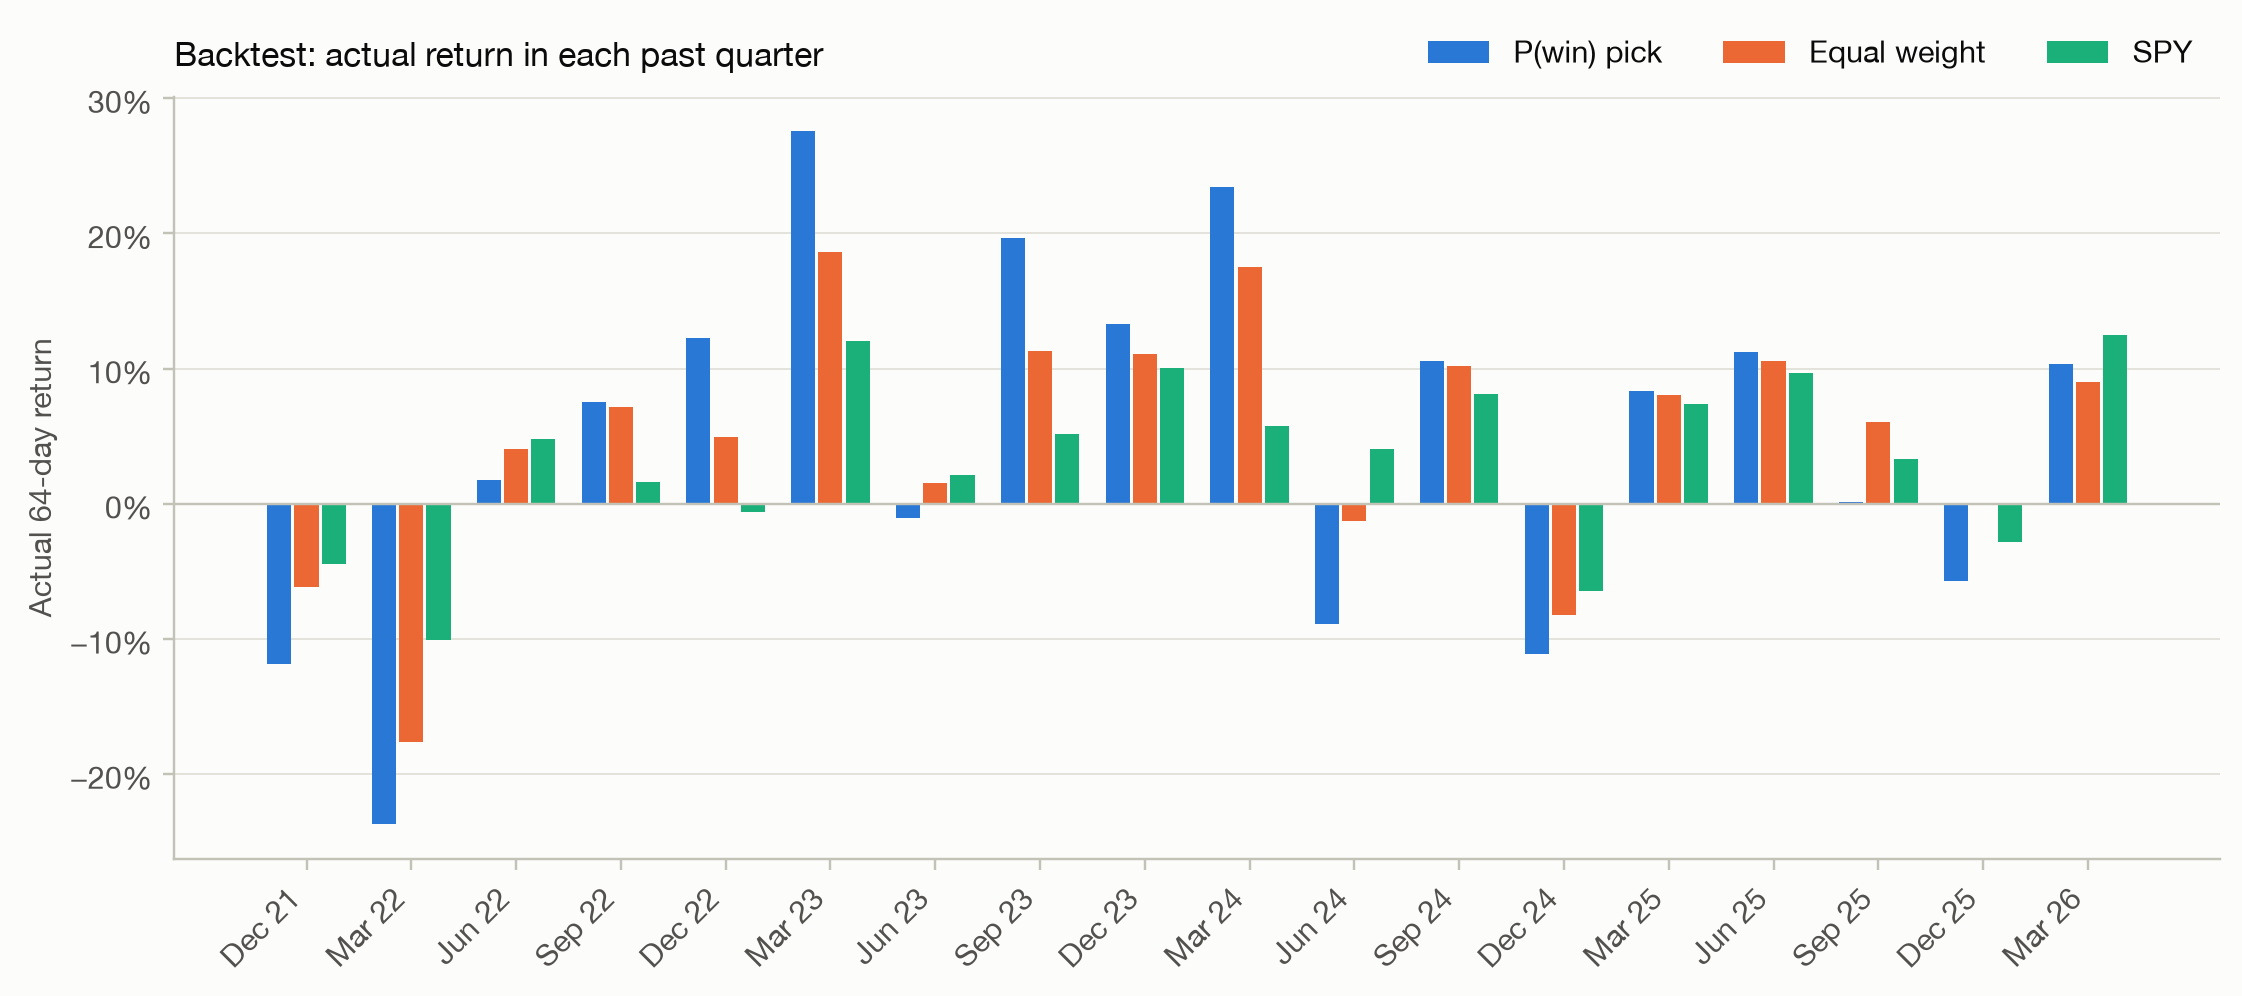

In [20]:
x = np.arange(QUARTERS)
bar_width = 0.26
fig, ax = plt.subplots(figsize=(12, 4.5))
for offset, key, color in [(-bar_width, "pick", charts.COLORS["blue"]), (0, "equal_weight", charts.COLORS["orange"]),
                           (bar_width, "spy", charts.COLORS["aqua"])]:
    ax.bar(x + offset, history_test[f"{key}_return"], width=bar_width - 0.03, color=color, label=strategies[key])
ax.axhline(0, color=charts.INK["axis"], linewidth=0.8)
ax.set_xticks(x, [f"{d:%b %y}" for d in history_test.index], rotation=45, ha="right")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel(f"Actual {HORIZON}-day return")
ax.legend(loc="lower right", bbox_to_anchor=(1, 1), ncols=3)
ax.set_title("Backtest: actual return in each past quarter")
charts.save_figure(fig, "backtest")
plt.show()

**How to read this chart:** each group of bars is one past quarter. The pick's bars are usually the tallest in strong markets and the deepest in weak ones: it amplifies whatever the market does, which is exactly the behavior that wins contests (and loses them).

## 10. Final allocation

Dollar amounts come from the final pick's weights. Share counts use the **latest closing price** as a reference; the actual counts depend on the price paid on Sep 14. The allocation is saved to `results/allocation.csv`, which the tracking notebook reads.

In [21]:
allocation = pd.DataFrame({
    "ticker": TICKERS,
    "weight": final_weights.round(4),
    "dollars": (CAPITAL * final_weights).round(2),
    "ref_price": prices[TICKERS].iloc[-1].round(2).to_numpy(),
})
allocation["shares"] = (allocation["dollars"] / allocation["ref_price"]).round(4)
allocation["ref_date"] = f"{LAST_DATE:%Y-%m-%d}"
allocation = allocation.sort_values(["weight", "ticker"], ascending=[False, True]).reset_index(drop=True)

assert np.isclose(allocation["weight"].sum(), 1.0, atol=1e-6)
assert allocation["weight"].between(MIN_WEIGHT - 1e-9, MAX_WEIGHT + 1e-9).all()
assert np.isclose(allocation["dollars"].sum(), CAPITAL, atol=0.01)
RESULTS_DIR.mkdir(exist_ok=True)
allocation.to_csv(RESULTS_DIR / "allocation.csv", index=False)

display(allocation.style.hide(axis="index")
        .set_caption(f"Capital ${CAPITAL:,.0f} · reference prices from {LAST_DATE:%Y-%m-%d}")
        .format({"weight": "{:.1%}", "dollars": "${:,.2f}", "ref_price": "${:,.2f}", "shares": "{:,.4f}"}))

pick_row, equal_row = comparison.loc["Final pick"], comparison.loc["Equal weight"]
display(Markdown(f"""
| | Final pick | Equal weight |
|---|---|---|
| Chance of finishing 1st of {N_RIVALS + 1} | **{pick_row['P(win)']:.1%}** | {equal_row['P(win)']:.1%} |
| Chance of finishing in the top 3 | {pick_row['P(top 3)']:.1%} | {equal_row['P(top 3)']:.1%} |
| Chance of losing money | {pick_row['P(loss)']:.1%} | {equal_row['P(loss)']:.1%} |
| Median 3-month return | {pick_row['median']:+.1%} | {equal_row['median']:+.1%} |
| Bad case (5th percentile) | {pick_row['5th pct']:+.1%} | {equal_row['5th pct']:+.1%} |
| Good case (95th percentile) | {pick_row['95th pct']:+.1%} | {equal_row['95th pct']:+.1%} |

A random rival's chance of finishing first is {1 / (N_RIVALS + 1):.1%}.
"""))

ticker,weight,dollars,ref_price,shares,ref_date
GOOGL,20.0%,"$20,000.00",$338.50,59.0842,2026-09-11
NVDA,20.0%,"$20,000.00",$218.29,91.6212,2026-09-11
SNAP,20.0%,"$20,000.00",$5.68,"3,521.1268",2026-09-11
BSY,10.0%,"$10,000.00",$30.97,322.8931,2026-09-11
AAPL,5.0%,"$5,000.00",$332.27,15.0480,2026-09-11
CAT,5.0%,"$5,000.00",$818.57,6.1082,2026-09-11
COST,5.0%,"$5,000.00",$904.77,5.5263,2026-09-11
DE,5.0%,"$5,000.00",$675.74,7.3993,2026-09-11
JPM,5.0%,"$5,000.00",$356.23,14.0359,2026-09-11
NEE,5.0%,"$5,000.00",$82.31,60.7460,2026-09-11



| | Final pick | Equal weight |
|---|---|---|
| Chance of finishing 1st of 21 | **11.3%** | 3.0% |
| Chance of finishing in the top 3 | 23.4% | 11.7% |
| Chance of losing money | 40.7% | 37.4% |
| Median 3-month return | +3.2% | +3.3% |
| Bad case (5th percentile) | -18.6% | -14.0% |
| Good case (95th percentile) | +26.9% | +20.1% |

A random rival's chance of finishing first is 4.8%.


## 11. What we learned

In [22]:
heavy = [TICKERS[i] for i in np.argsort(-final_weights) if final_weights[i] >= 0.15]
others = [t for t in TICKERS if t not in heavy]
heavy_profile = ", ".join(
    f"{t} ({stock_table.loc[t, 'annual_vol']:.0%} volatility, beta {stock_table.loc[t, 'beta']:.1f})" for t in heavy
)
view_best = {v: int(candidates[int(np.argmax(confirm[v]["p_win"].to_numpy()))]) for v in VIEWS}
view_leaders = [{TICKERS[i] for i in np.flatnonzero(search.weights_from_units(units[view_best[v]], MIN_WEIGHT,
                                                                             GRID_STEP) >= 0.15)} for v in VIEWS]
always_heavy = sorted(set.intersection(*view_leaders), key=TICKERS.index)
leaders_text = (" and ".join([", ".join(always_heavy[:-1]), always_heavy[-1]]) if len(always_heavy) > 1
                else always_heavy[0] if always_heavy else "No single stock")
leaders_verb = "get" if len(always_heavy) > 1 else "gets"
fine_gain = validation["P(win) avg"].iloc[1] - validation["P(win) avg"].iloc[0]
fine_sentence = (f"Fine-tuning from {GRID_STEP:.1%} to {FINE_STEP:.0%} steps raised P(win) by {fine_gain * 100:.2f} "
                 "percentage points on fresh simulations, so the fine-tuned weights were kept."
                 if FINAL_NAME.startswith("Fine") else
                 f"Fine-tuning from {GRID_STEP:.1%} to {FINE_STEP:.0%} steps did not beat the grid pick on fresh "
                 "simulations, so the simpler grid weights were kept.")
display(Markdown(f"""
**1. Winning and investing well are different goals.** The final pick and equal weight have almost the same median
return ({pick_row['median']:+.1%} vs {equal_row['median']:+.1%}), yet the pick is about
**{pick_row['P(win)'] / equal_row['P(win)']:.1f}× as likely to finish first** ({pick_row['P(win)']:.1%} vs
{equal_row['P(win)']:.1%}). The price: a {pick_row['P(loss)']:.0%} chance of losing money
(equal weight: {equal_row['P(loss)']:.0%}).

**2. Volatility is the main lever, not forecasts.** The biggest positions are {heavy_profile}. The other
{len(others)} stocks average {stock_table.loc[others, 'annual_vol'].mean():.0%} volatility and beta
{stock_table.loc[others, 'beta'].mean():.1f}. {leaders_text} {leaders_verb} at least 15% in the best
portfolio of every expected-return view, including views that expect little from them. In a contest, a stock's
*spread* of outcomes matters as much as its expected return.

**3. Diversification narrows both tails.** Spreading money evenly makes a large loss less likely, but it also
makes a first-place finish unlikely. That is great for real savings and poor for a winner-take-all contest.

**4. The history test is encouraging but not proof.** Over {QUARTERS} past quarters the P(win) pick beat random
rival fields {history_test['pick_field_win'].mean():.1%} of the time, against
{history_test['equal_weight_field_win'].mean():.1%} for equal weight and
{1 / (N_RIVALS + 1):.1%} for a random rival. But the wins came from only {WINNING_QUARTERS} strong quarters, and its
average return ({history_test['pick_return'].mean():+.1%} per quarter) was no better than equal weight
({history_test['equal_weight_return'].mean():+.1%}). It wins by occasionally finishing far ahead, not by earning more.

**5. Precision has limits.** {fine_sentence} With 3-month returns this noisy, the useful decisions are the big
ones: which stocks get the most money.
"""))


**1. Winning and investing well are different goals.** The final pick and equal weight have almost the same median
return (+3.2% vs +3.3%), yet the pick is about
**3.7× as likely to finish first** (11.3% vs
3.0%). The price: a 41% chance of losing money
(equal weight: 37%).

**2. Volatility is the main lever, not forecasts.** The biggest positions are NVDA (50% volatility, beta 2.0), SNAP (77% volatility, beta 1.6), GOOGL (31% volatility, beta 1.2). The other
7 stocks average 29% volatility and beta
0.9. NVDA and SNAP get at least 15% in the best
portfolio of every expected-return view, including views that expect little from them. In a contest, a stock's
*spread* of outcomes matters as much as its expected return.

**3. Diversification narrows both tails.** Spreading money evenly makes a large loss less likely, but it also
makes a first-place finish unlikely. That is great for real savings and poor for a winner-take-all contest.

**4. The history test is encouraging but not proof.** Over 18 past quarters the P(win) pick beat random
rival fields 13.4% of the time, against
4.1% for equal weight and
4.8% for a random rival. But the wins came from only 4 strong quarters, and its
average return (+4.7% per quarter) was no better than equal weight
(+4.8%). It wins by occasionally finishing far ahead, not by earning more.

**5. Precision has limits.** Fine-tuning from 2.5% to 1% steps did not beat the grid pick on fresh simulations, so the simpler grid weights were kept. With 3-month returns this noisy, the useful decisions are the big
ones: which stocks get the most money.


### Lessons for future stock-picking assignments
1. **Start from the rules.** How the contest is scored (highest return, risk-adjusted return, beating an index) decides which portfolio is "best".
2. **Back each reason with data.** A sector check, a correlation table and a volatility figure turn "I think" into "the data shows".
3. **Treat diversification as a decision.** Know what it buys (fewer disasters) and what it costs (fewer big wins).
4. **Give ranges, not point forecasts.** "Somewhere between −20% and +25%" is more honest and more useful than "+5%".
5. **Test ideas on history, and report the result honestly,** including when the evidence is thin.

## 12. Caveats and experiments to try

**Caveats**
- **This is a model, not a guarantee.** Three-month returns are mostly noise. The notebook improves the odds; even the best portfolio loses the contest most of the time.
- **The rivals are guesses.** Real classmates' stocks and weights are unknown. If they favor very volatile stocks, winning takes a higher return than simulated.
- **History has limits.** The window (late 2020 to today) includes an AI-driven boom in tech stocks, the 2022 bear market and unusually high volatility for growth stocks such as BSY and SNAP.
- **Educational project, not investment advice.**

**Experiments** (change a setting in section 1, then run all cells)
- Set `HALF_LIFE_YEARS = 2` to weight recent years more. Does the pick change?
- Set `N_RIVALS = 5` or `50`. With fewer rivals, does a less aggressive portfolio win more often?
- Set `VIEW_WEIGHTS = {"neutral": 1, "momentum": 0, "analyst": 0, "trend": 0}` to rely on CAPM alone.
- Set `MAX_WEIGHT = 0.30` to see how much more concentrated the pick becomes when the rules allow it.